In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import chisquare

# Set Arial font for all text
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42

pnas_fontsize = 8

## S8B: Regrowth Probability vs Distance to PA

In [3]:
# =============================================================================
# LOAD DATA
# =============================================================================
chamber_wt = pd.read_csv('../../../Figure1/1E_wt/figure_code/1_regrowth_fractions_wt_per_chamber.csv')
chamber_pa_removed = pd.read_csv('1_regrowth_fractions_pa_flush_per_chamber.csv')


### Helper Functions

In [4]:
# =============================================================================
# HELPER FUNCTIONS (MATCHING SCRIPT 1)
# =============================================================================
def plot_with_shade(ax, mean, std, x, label, color):
    """Plot mean ± std as line + shaded area"""
    line = ax.plot(x, mean, label=label, color=color, linewidth=1)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.3)
    return line[0]

def extract_stats(df, axis='y'):
    """Extract mean and std from per-chamber data"""
    df_axis = df[df['axis'] == axis].copy().sort_values('bin_left')
    # Compute stats from raw chamber data
    stats = df_axis.groupby('bin_left')['regrowth_fraction'].agg(
        mean_regrowth_fraction='mean',
        std_regrowth_fraction=lambda x: np.std(x, ddof=1)
    ).reset_index()
    return (stats['mean_regrowth_fraction'].values,
            stats['std_regrowth_fraction'].values,
            stats['bin_left'].values)

### Extract Statistics

In [5]:
# =============================================================================
# EXTRACT STATS
# =============================================================================
wt_mean, wt_std, wt_x = extract_stats(chamber_wt)
removed_mean, removed_std, removed_x = extract_stats(chamber_pa_removed)

### Plot S8B: Distance to PA

✅ Figure saved: S8B_pa_removed_yaxis.pdf


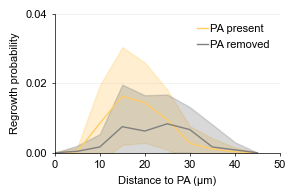

In [6]:
# =============================================================================
# CREATE FIGURE - 2 WIDTH x 3 HEIGHT (INCHES)
# =============================================================================
fig, ax = plt.subplots(figsize=(3, 2))

# Plot both datasets
line_wt = plot_with_shade(ax, wt_mean, wt_std, wt_x, 
                          'PA present', '#ffcc66')
line_removed = plot_with_shade(ax, removed_mean, removed_std, removed_x, 
                               'PA removed', 'grey')

# Labels
ax.set_xlabel('Distance to PA (µm)', fontsize=pnas_fontsize)
ax.set_ylabel('Regrowth probability', fontsize=pnas_fontsize)

# Limits and ticks
ax.set_xlim(0, 50)
ax.set_ylim(0, 0.04)
ax.set_xticks([0, 10, 20, 30, 40, 50])
ax.set_yticks([0.00, 0.02, 0.04])

# =============================================================================
# CHARTOSAUR STYLE (MATCHING SCRIPT 1)
# =============================================================================
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(axis='both', which='major', width=0.5, length=2, 
               labelsize=pnas_fontsize)
ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)

# Legend
ax.legend(frameon=False, fontsize=pnas_fontsize, loc='upper right',
          handlelength=1, handletextpad=0.2)

plt.tight_layout()

# Save as PDF with 300 DPI
output_pdf = 'S8B_pa_removed_yaxis.pdf'
plt.savefig(output_pdf, dpi=300, bbox_inches='tight')

print(f"✅ Figure saved: {output_pdf}")
plt.show()


### Statistics — Chi-square test

In [8]:
b_mean = 148.46  # replace if a different denominator was used

# Load per-chamber datasets
real = pd.read_csv('../../../Figure1/1E_wt/figure_code/1_regrowth_fractions_wt_per_replicate.csv')
null = pd.read_csv('1_regrowth_fractions_pa_flush_per_replicate.csv')

# Convert fractions to counts (no rounding to avoid mismatch)
real['count'] = real['regrowth_fraction'] * b_mean
null['count'] = null['regrowth_fraction'] * b_mean

# Observed totals per bin (summing replicates)
real_observed = (real
                 .groupby(['axis', 'bin_left'], as_index=False)
                 .agg(observed_count=('count', 'sum')))

# Expected counts per bin (averaging across replicates/draws, then rescale)
null_expected = (null
                 .groupby(['axis', 'bin_left'], as_index=False)
                 .agg(expected_count=('count', 'mean')))

merged = real_observed.merge(null_expected, on=['axis', 'bin_left'])

results = []
for axis in ['x', 'y']:
    subset = merged[merged['axis'] == axis].copy()
    observed = subset['observed_count'].to_numpy()
    expected = subset['expected_count'].to_numpy()
    
    # Add pseudocount to handle zeros
    observed = observed + 0.5
    expected = expected + 0.5
    
    # Rescale expected counts to match observed total
    expected *= observed.sum() / expected.sum()
    
    chi2, p = chisquare(f_obs=observed, f_exp=expected)
    
    results.append({
        'axis': axis,
        'chi2': chi2,
        'degrees_of_freedom': len(observed) - 1,
        'p_value': p
    })

print(pd.DataFrame(results))

# Interpretation
print("\nInterpretation:")
for result in results:
    axis = result['axis']
    chi2 = result['chi2']
    p = result['p_value']
    
    if p < 0.001:
        sig = "*** HIGHLY SIGNIFICANT (p < 0.001)"
    elif p < 0.01:
        sig = "** SIGNIFICANT (p < 0.01)"
    elif p < 0.05:
        sig = "* SIGNIFICANT (p < 0.05)"
    else:
        sig = "not significant (p >= 0.05)"
    
    print(f"{axis.upper()}-axis: χ² = {chi2:.2f}, p = {p:.2e} → {sig}")


  axis       chi2  degrees_of_freedom   p_value
0    x   5.260313                   9  0.811051
1    y  10.639112                   9  0.301259

Interpretation:
X-axis: χ² = 5.26, p = 8.11e-01 → not significant (p >= 0.05)
Y-axis: χ² = 10.64, p = 3.01e-01 → not significant (p >= 0.05)
